In [3]:
import os 
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

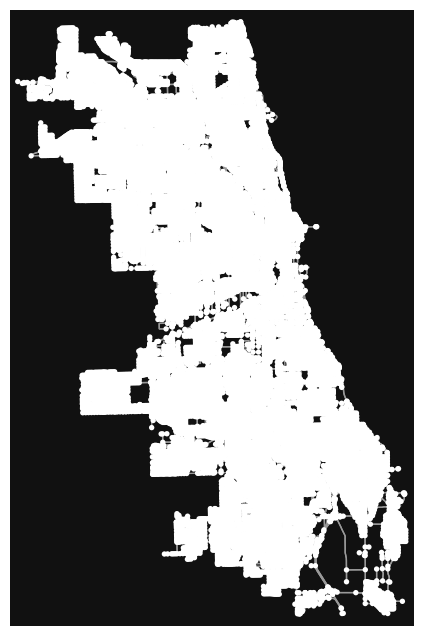

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
import osmnx as ox

## IMPORT CITY
city = ox.graph_from_place('Chicago, IL, USA', network_type='drive')

ox.plot_graph(city)

In [5]:
import networkx as nx
import numpy as np

## ADDING EDGE PROPERTIES
city = ox.speed.add_edge_speeds(city)
city = ox.speed.add_edge_travel_times(city)

## GENERATING IMPORTANT INFO
indexes = {node: i for i, node in enumerate(city.nodes)}
travel_times_dict = nx.get_edge_attributes(city, 'travel_time')

from utils import node_from_address, get_unique_path

In [6]:
## FILTERING OUT UNDESIRABLE NODES, GENERATING INCIDENCE MATRIX

'''banned_coords = [(40.130902, -88.243662), 
                (40.130462, -88.238855), 
                (40.132660, -88.243546),
                (40.132989, -88.257875),
                (40.127197, -88.245215)]

banned_nodes = [ox.nearest_nodes(city, lon, lat) for lat, lon in banned_coords]'''

banned_nodes = []
banned_edges = []
banned_edges_idx = []

edges = list(city.edges)

n_points = len(city.nodes)
n_edges = len(city.edges)

A = np.zeros((n_points, n_edges))

for i, (u, v, k) in enumerate(edges):
    if u in banned_nodes or v in banned_nodes:
        banned_edges += [(u, v, k)]
        banned_edges_idx += [i]
        pass

    A[indexes[u]][i] = -1
    A[indexes[v]][i] = 1

In [18]:
## LINEAR PROGRAM LOGIC
import gurobipy as gp
from gurobipy import GRB
import json
import tqdm
import importlib
import utils
    
importlib.reload(utils)

unrestricted_path_lengths = {}

centroids = json.load(open('./data/tract-centroids.json'))
red_nodes = json.load(open('./banned_nodes.json'))

final_node = ox.nearest_nodes(city, -87.851528, 41.984025)

m = gp.Model("lp")
m.Params.LogToConsole = 0
m.Params.Method = 0

weights = [travel_time for edge, travel_time in travel_times_dict.items()]

f = m.addMVar(shape=n_edges, vtype=GRB.INTEGER, lb=0, name="")

obj = np.array(weights)@f

m.setObjective(obj, GRB.MINIMIZE)
for i in tqdm.trange(len(centroids)):
    tract = list(centroids.keys())[i]
    unrestricted_path_lengths[tract] = {}
    lon, lat = centroids[tract]

    starting_node = ox.nearest_nodes(city, lon, lat)
    b = np.zeros(n_points)
    b[indexes[starting_node]] = -1
    b[indexes[final_node]] = 1


    m.remove(m.getConstrs())
    m.addConstr(A@f==b)

    #m.addConstr(gp.quicksum(f[i] for i in banned_edges_idx) <= ((max_budget)-budget)*2)

    m.optimize()

    flows = m.getAttr("X", m.getVars())

    objval = m.ObjVal

    print(f'{tract} -> {int(objval//60)}m{round(objval%60)}s, {objval}s')
    
    
    unrestricted_path_lengths[tract]['length']=objval
    flowed_edges_idx = []
    flowed_edges = []

    for i in range(len(flows)):
        if flows[i]:
            #print(flows[i])
            flowed_edges_idx += [i]

    flowed_pts = []

    for i, (u, v, k) in enumerate(city.edges):
        if i in flowed_edges_idx:
            flowed_edges += [(u, v, k)]
            #if i in banned_edges_idx:
                #print(i, edges[i])

            for pt in (u, v):
                if pt not in flowed_pts:
                    flowed_pts += [pt]
    
    path, pts = utils.get_edges_and_points(flowed_edges, starting_node=starting_node, final_node=final_node)
    unrestricted_path_lengths[tract]['n_banned_nodes'] = len([pt for pt in pts if pt in red_nodes])
    print(unrestricted_path_lengths[tract])
    continue

    '''fig, ax = ox.plot_graph_route(city, pts, node_color='w', node_edgecolor='k', node_size=0, 
                            node_zorder=3, edge_linewidth=2)'''

  0%|          | 1/801 [00:09<2:10:23,  9.78s/it]

Census Tract 8424 -> 27m52s, 1672.3999999999999s
{'length': 1672.3999999999999, 'n_banned_nodes': 0}


  0%|          | 1/801 [00:18<4:09:21, 18.70s/it]


KeyboardInterrupt: 

In [11]:
import json

camera_data = json.load(open('./data/cameras.json', 'r'))
camera_nodes = []
for row in camera_data['data']:
    lat, lon = row[-3:-1]

    camera_nodes += [ox.nearest_nodes(city, float(lon), float(lat))]

In [13]:
json.dump(camera_nodes, open('./data/banned_nodes.json', 'w'))

Path length: 37m16s, 2236.5s


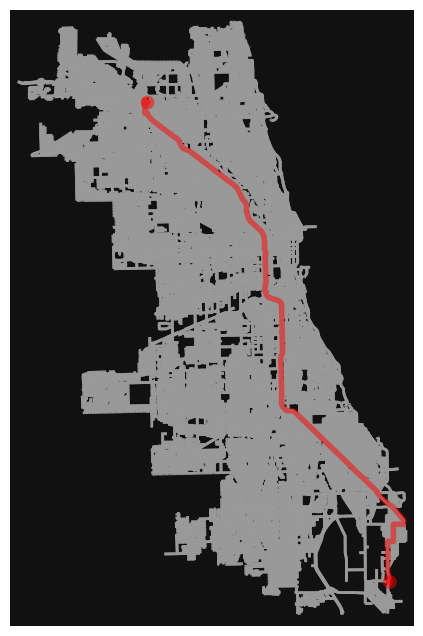

In [18]:
## TESTING FOR DIFFERENT BUDGETS
max_budget = 0
for budget in range(max_budget+1):
    m.addConstr(gp.quicksum(f[i] for i in banned_edges_idx) <= ((max_budget)-budget)*2)

    m.optimize()

    flows = m.getAttr("X", m.getVars())

    objval = m.ObjVal

    print(f'Path length: {int(objval//60)}m{round(objval%60)}s, {objval}s')

    flowed_edges_idx = []
    flowed_edges = []

    for i in range(len(flows)):
        if flows[i]:
            #print(flows[i])
            flowed_edges_idx += [i]

    flowed_pts = []

    for i, (u, v, k) in enumerate(city.edges):
        if i in flowed_edges_idx:
            flowed_edges += [(u, v, k)]
            #if i in banned_edges_idx:
                #print(i, edges[i])

            for pt in (u, v):
                if pt not in flowed_pts:
                    flowed_pts += [pt]
    import importlib
    import utils
    importlib.reload(utils)
    path, pts = utils.get_edges_and_points(flowed_edges, starting_node=starting_node, final_node=final_node)

    fig, ax = ox.plot_graph_route(city, pts, node_color='w', node_edgecolor='k', node_size=0, 
                            node_zorder=3, edge_linewidth=2)

In [12]:
for current_edge in flowed_edges:
    matching_edges = [edge for edge in flowed_edges if edge[0] == current_edge[1]]
    if len(matching_edges) >= 2: print(current_edge)

In [7]:
def get_edges_for_real_local(edges: list, starting_node: int, final_node: int) -> list:
    matching_edges = [edge for edge in edges if edge[0] == starting_node]

    if len(matching_edges) == 1 and matching_edges[0][1] == final_node:
        return matching_edges

    for matching_edge in matching_edges:
        all_edges = get_edges_for_real_local([edge for edge in edges if edge != matching_edge], matching_edge[1], final_node)
        
        return all_edges + [matching_edge]

In [8]:
get_edges_for_real_local(flowed_edges, starting_node, final_node)

[(5440546962, 2375296144, 0),
 (5440546961, 5440546962, 0),
 (1518917867, 5440546961, 0),
 (194668461, 1518917867, 0),
 (38133216, 194668461, 0),
 (37963930, 38133216, 0),
 (38146585, 37963930, 0),
 (3273524767, 38146585, 0),
 (6119772432, 3273524767, 0),
 (1929711603, 6119772432, 0),
 (1929711495, 1929711603, 0),
 (6119772436, 1929711495, 0),
 (5680618729, 6119772436, 0),
 (5680617585, 5680618729, 0),
 (10101649870, 5680617585, 0),
 (10101649866, 10101649870, 0),
 (10101638415, 10101649866, 0),
 (38009741, 10101638415, 0),
 (37986833, 38009741, 0),
 (38009732, 37986833, 0),
 (38009731, 38009732, 0),
 (37970446, 38009731, 0),
 (38009727, 37970446, 0),
 (37999274, 38009727, 0),
 (38128444, 37999274, 0),
 (37982955, 38128444, 0),
 (38047403, 37982955, 0),
 (38068242, 38047403, 0),
 (38007920, 38068242, 0),
 (37989318, 38007920, 0),
 (38003956, 37989318, 0),
 (37997462, 38003956, 0),
 (38083033, 37997462, 0),
 (38135457, 38083033, 0),
 (38135864, 38135457, 0),
 (38035942, 38135864, 0),
 (